# NSE and Reliance

In [84]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [85]:
end = dt.datetime.today()
start = end - dt.timedelta(days=365*10)

In [86]:
nse = yf.download('^NSEI', start, end,auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [87]:
rel = yf.download('RELIANCE.NS',start,end,auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [88]:
nse.columns = nse.columns.droplevel(1)
rel.columns = rel.columns.droplevel(1)

In [89]:
nse.columns = nse.columns.str.lower()
rel.columns = rel.columns.str.lower()
nse.drop(columns=['high','low','open','volume'], inplace=True)
rel.drop(columns=['high','low','open','volume'], inplace=True)
nse.index = pd.to_datetime(nse.index)
rel.index = pd.to_datetime(rel.index)

MAE:  0.006707628177327096
MSE:  8.801790098893268e-05
RMSE:  0.009381785597045621
                            OLS Regression Results                            
Dep. Variable:            rel_returns   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     1213.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):          1.35e-201
Time:                        14:08:05   Log-Likelihood:                 4893.4
No. Observations:                1723   AIC:                            -9783.
Df Residuals:                    1721   BIC:                            -9772.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

Text(0, 0.5, 'Predicted')

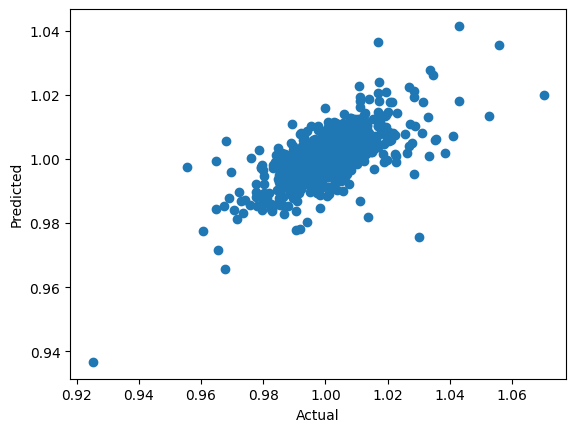

In [90]:
nse['nse_returns'] = (nse['close'] / nse['close'].shift(1))
rel['rel_returns'] = (rel['close'] / rel['close'].shift(1))
x = nse['nse_returns']
y = rel['rel_returns']
data = pd.concat([x,y],axis=1).dropna()
split = int(len(data) * 0.7)
train = data.iloc[:split]
test = data.iloc[split:]
x_train = train['nse_returns']
y_train = train['rel_returns']
x_test = test['nse_returns']
y_test = test['rel_returns']

# Constant and Model
x_train = sm.add_constant(x_train)
x_test = sm.add_constant(x_test)
model = sm.OLS(y_train,x_train).fit()

# prediction
pred = model.predict(x_test)

error = y_test - pred
mae = np.mean(np.abs(error))
mse = np.mean(error**2)
rmse = np.sqrt(mse)

# R2
ss_res = np.sum(error**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res / ss_tot)

# Adjusted R2
n = len(y_test)
k = 1   # only 1 feature (nifty)
adj_r2 = 1 - ((1 - r2)*(n - 1)/(n - k - 1))
# Stats Summary
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print(model.summary())

# Plotting
plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")